# Graphiques en Python avec matplotlib et seaborn


# Objectifs du TP

TP de **2h**. Vous allez :

* (Re)voir les bases de **matplotlib** (API `pyplot` et API objet), personnalisation (légendes, axes, styles, grilles, annotations) et sauvegarde des figures.
* Découvrir **seaborn** pour des graphiques statistiques expressifs adossés à des DataFrames `pandas`.
* Réaliser des **exercices** à partir de jeux de données standards (packages Python) ou téléchargeables en ligne.

> Prérequis : Avoir `matplotlib` et `seaborn` installés.

---

# Partie 1 · matplotlib (bases solides)

La bibliothèque **matplotlib** est la fondation de l’écosystème de visualisation Python. Deux styles d’utilisation coexistent :

- **API `pyplot`** (rapide, état global) via `import matplotlib.pyplot as plt`.
- **API orientée objet** (recommandée pour des figures complexes) où l’on manipule explicitement des objets `Figure` et `Axes`.

## Démarrage rapide (pyplot)

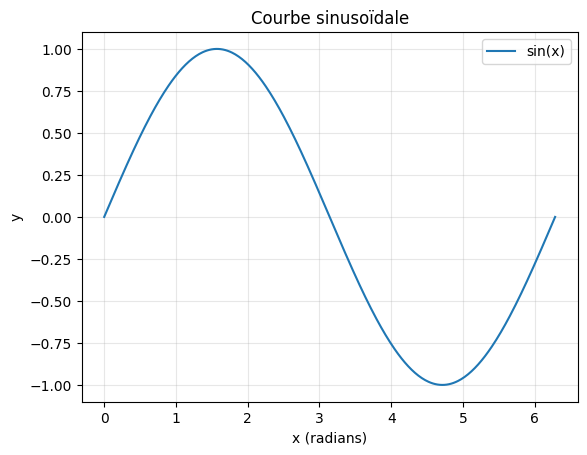

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 2*np.pi, 400)
y = np.sin(x)

plt.plot(x, y, label="sin(x)")
plt.title("Courbe sinusoïdale")
plt.xlabel("x (radians)")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Démarrage rapide (API objet)

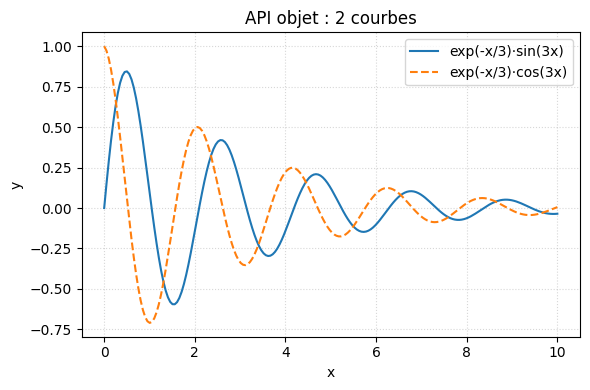

In [6]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 200)
y1 = np.exp(-x/3) * np.sin(3*x)
y2 = np.exp(-x/3) * np.cos(3*x)

fig, ax = plt.subplots(figsize=(6,4))  # un objet Figure et un Axes
ax.plot(x, y1, label="exp(-x/3)·sin(3x)")
ax.plot(x, y2, label="exp(-x/3)·cos(3x)", linestyle="--")
ax.set(title="API objet : 2 courbes", xlabel="x", ylabel="y")
ax.legend()
ax.grid(True, linestyle=":", alpha=0.5)
fig.tight_layout()
plt.show()

## Familles de graphiques courantes (matplotlib)

### Graphiques 1D / séries temporelles

| But                | Fonction(s) `pyplot` | Notes                                                                 |
| ------------------ | -------------------- | --------------------------------------------------------------------- |
| Courbe simple      | `plot`               | style de ligne (`linestyle`), marqueurs (`marker`), couleur (`color`) |
| Aire sous courbe   | `fill_between`       | utile pour intervalles de confiance                                   |
| Tiges (impulsions) | `stem`               | séries discrètes                                                      |
| Séries temporelles | `plot_date` / `plot` | gérer les dates (formatters)                                          |

### Graphiques de distribution

| But                | Fonction(s) `pyplot`                   | Notes                                                    |
| ------------------ | -------------------------------------- | -------------------------------------------------------- |
| Histogramme        | `hist`                                 | contrôle des classes avec `bins`, densité `density=True` |
| Densité lissée     | (via `scipy`, ou tracer sa propre KDE) | seaborn facilite cette tâche                             |
| Boîte à moustaches | `boxplot`                              | comparer des distributions                               |
| Violon             | `violinplot`                           | forme de la densité                                      |

### Graphiques 2D / relationnels

| But              | Fonction(s) `pyplot` | Notes                                                   |
| ---------------- | -------------------- | ------------------------------------------------------- |
| Nuage de points  | `scatter`            | taille `s`, transparence `alpha`, couleur par catégorie |
| Courbe + points  | `plot`, `scatter`    | superposition                                           |
| Hexbin / 2D hist | `hexbin`, `hist2d`   | denses nuages de points                                 |

### Catégoriel / barres

| But               | Fonction(s) `pyplot`   | Notes                    |
| ----------------- | ---------------------- | ------------------------ |
| Barres verticales | `bar`                  | `barh` pour horizontal   |
| Barres empilées   | `bar(..., bottom=...)` | cumuler des séries       |
| Barres groupées   | décalage sur l’axe x   | gérer la largeur `width` |

### Cartes de chaleur / images

| But              | Fonction(s) `pyplot`   | Notes                         |
| ---------------- | ---------------------- | ----------------------------- |
| Image / matrice  | `imshow`               | `aspect`, `cmap`, `vmin/vmax` |
| Carte de chaleur | `imshow`, `pcolormesh` | pour matrices / corrélations  |

## Légendes et annotations

* **Légendes** : ajouter `label=` dans vos tracés, puis `plt.legend()` (pyplot) ou `ax.legend()` (objet). Paramètres utiles : `loc`, `bbox_to_anchor`, `ncol`, `frameon`.
* **Annotations ponctuelles** : `plt.annotate("texte", xy=(x0,y0), xytext=(x1,y1), arrowprops={...})`.
* **Texte libre** : `plt.text(x, y, "contenu", fontsize=..., ha="center", va="bottom")`.

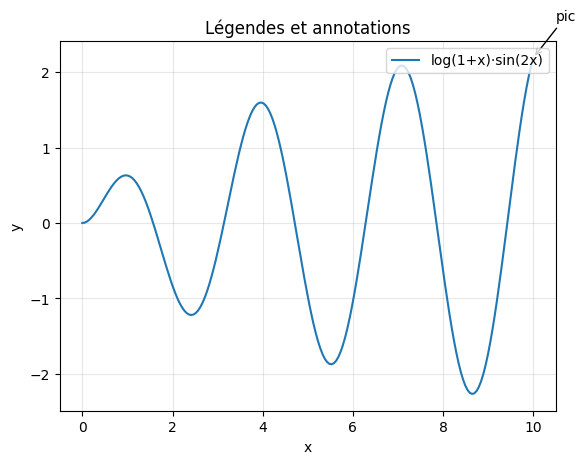

In [7]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 200)
y = np.log1p(x) * np.sin(2*x)

fig, ax = plt.subplots()
ax.plot(x, y, label="log(1+x)·sin(2x)")
ax.legend(loc="upper right")
ax.set_title("Légendes et annotations")
ax.set_xlabel("x")
ax.set_ylabel("y")
# Annotation d'un maximum approché
imax = np.argmax(y)
ax.annotate("pic", xy=(x[imax], y[imax]), xytext=(x[imax]+0.5, y[imax]+0.5),
            arrowprops=dict(arrowstyle="->", lw=1))
ax.grid(True, alpha=0.3)
plt.show()

## Mise en forme des axes

- **Titres et étiquettes** : `ax.set_title`, `ax.set_xlabel`, `ax.set_ylabel`.
- **Bornes** : `ax.set_xlim(min, max)`, `ax.set_ylim(min, max)`.
- **Échelle** : `ax.set_xscale("log")`, `ax.set_yscale("symlog")`, etc.
- **Graduations (ticks)** : `ax.set_xticks([...])`, `ax.set_xticklabels([...])` (attention à la rotation), `ax.tick_params(labelsize=..., direction=...)`.
- **Format des nombres** : via `matplotlib.ticker` (`FuncFormatter`, `ScalarFormatter`, `PercentFormatter`).
- **Second axe** : `ax.twinx()` / `ax.twiny()` pour unités différentes.

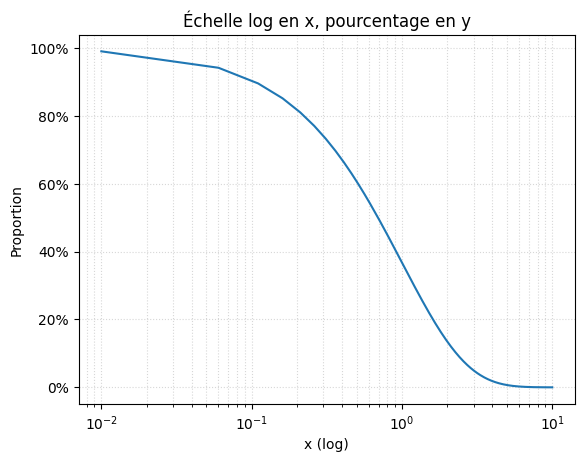

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

x = np.linspace(0.01, 10, 200)
y = np.exp(-x)

fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_xscale("log")
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set(title="Échelle log en x, pourcentage en y", xlabel="x (log)", ylabel="Proportion")
ax.grid(True, which="both", ls=":", alpha=0.5)
plt.show()

## Styles, sous-figures et sauvegarde

- **Styles** : `plt.style.use("seaborn-v0_8-darkgrid")`, `"ggplot"`, `"Solarize_Light2"`, etc. Liste via `plt.style.available`.
- **Sous-figures** : `fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8,6), sharex=True)` puis `axes[i,j].plot(...)`.
- **Disposition** : `fig.tight_layout()`, ou `from matplotlib.gridspec import GridSpec` pour des grilles avancées.
- **Sauvegarde** : `plt.savefig("figure.png", dpi=300, bbox_inches="tight")` (avant `plt.show()` pour éviter des surprises).

[0 1 2 3 4 5 6 7 8 9]


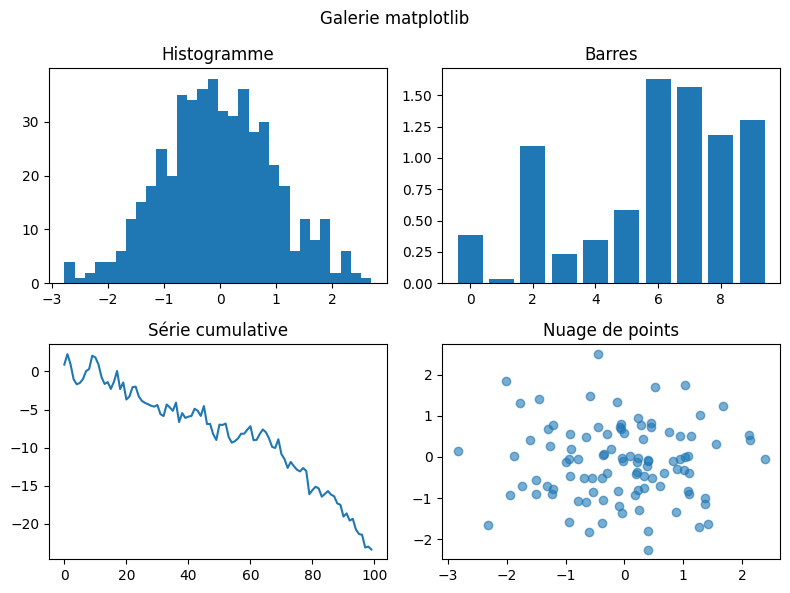

In [72]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
fig, axes = plt.subplots(2, 2, figsize=(8,6))

data = np.random.randn(500)
axes[0,0].hist(data, bins=30)
axes[0,0].set_title("Histogramme")

x = np.arange(10)
axes[0,1].bar(x, np.abs(np.random.randn(10)))
axes[0,1].set_title("Barres")

axes[1,0].plot(np.cumsum(np.random.randn(100)))
axes[1,0].set_title("Série cumulative")

axes[1,1].scatter(np.random.randn(100), np.random.randn(100), alpha=0.6)
axes[1,1].set_title("Nuage de points")

fig.suptitle("Galerie matplotlib", fontsize=12)
fig.tight_layout()
plt.show()

---

## Exercices matplotlib 

> Vous pouvez **charger** des jeux de données fournis par `seaborn` via `sns.load_dataset(...)`, **ou** télécharger les CSV depuis le dépôt : [https://github.com/mwaskom/seaborn-data](https://github.com/mwaskom/seaborn-data). Utilisez **matplotlib** pour réaliser les tracés (même si vous chargez avec seaborn/pandas).

1. **Iris — nuages de points par espèce**
   Chargez `iris` (`sns.load_dataset("iris")`). Avec **matplotlib**, tracez `sepal_length` vs `sepal_width` colorés par `species`, ajoutez légende, titres, et une **annotation** de la moyenne par espèce.

2. **Tips — barres groupées & intervalles**
   Chargez `tips`. Calculez le pourboire moyen par `day` et `sex`. Réalisez un **diagramme en barres groupées** avec barres d’erreur (écart-type ou IC95%). Légende propre, rotation des étiquettes si nécessaire.

3. **Flights — série temporelle et carte de chaleur**
   Chargez `flights`. Construisez une série `datetime` à partir de `year`/`month` et tracez l’évolution des `passengers` (ligne + points). Ensuite, pivotez en matrice (lignes = `year`, colonnes = `month`) et affichez une **carte de chaleur** (`imshow`) avec une barre de couleur et des **ticks** lisibles.

4. **Penguins — distributions comparées**
   Chargez `penguins`. Comparez la distribution de `flipper_length_mm` entre espèces via **histogrammes superposés** semi-transparents (`alpha`) **ou** via **violins** matplotlib (`plt.violinplot`). Ajoutez grille, légende, axes formatés.



### 1. Iris — nuages de points par espèce

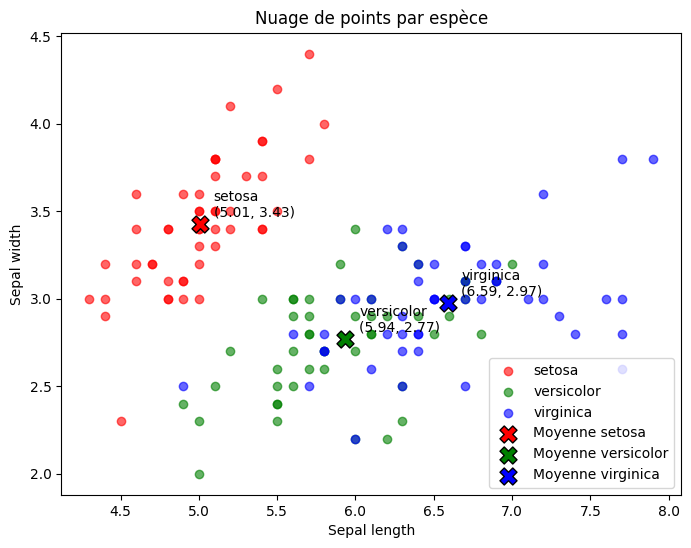

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
iris = sns.load_dataset("iris")
### Votre code ici
colors = {'setosa': 'red', 'versicolor': 'green', 'virginica': 'blue'}
fig, ax = plt.subplots(figsize=(8,6))
for species, group in iris.groupby("species"):
    ax.scatter(group["sepal_length"], group["sepal_width"],
               label=species, alpha=0.6, c=colors[species])
means = iris.groupby("species")[["sepal_length", "sepal_width"]].mean()
for species, row in means.iterrows():
    ax.scatter(row["sepal_length"], row["sepal_width"],
               c=colors[species], edgecolor="black",
               s=150, marker="X", label=f"Moyenne {species}")
    ax.annotate(f"{species}\n({row['sepal_length']:.2f}, {row['sepal_width']:.2f})",
                (row["sepal_length"], row["sepal_width"]),
                textcoords="offset points", xytext=(10,5))
ax.set_xlabel("Sepal length")
ax.set_ylabel("Sepal width")
ax.set_title("Nuage de points par espèce")
ax.legend()
plt.show()

### 2. Tips — barres groupées & intervalles

sex     day 
Male    Thur    2.980333
        Fri     2.693000
        Sat     3.083898
        Sun     3.220345
Female  Thur    2.575625
        Fri     2.781111
        Sat     2.801786
        Sun     3.367222
Name: tip, dtype: float64


C:\Users\thiba\AppData\Local\Temp\ipykernel_18832\4075904886.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_ts = tips.groupby('sex')[['tip']].mean()
C:\Users\thiba\AppData\Local\Temp\ipykernel_18832\4075904886.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_td = tips.groupby('day')[['tip']].mean()
C:\Users\thiba\AppData\Local\Temp\ipykernel_18832\4075904886.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this wa

AttributeError: 'Series' object has no attribute 'iterrows'

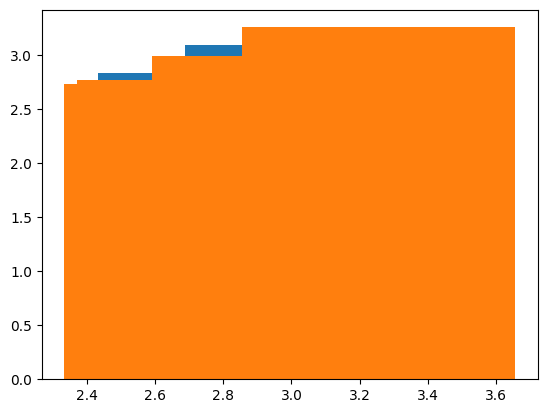

In [124]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
tips = sns.load_dataset("tips")

### Votre code ici
mean_ts = tips.groupby('sex')[['tip']].mean()
mean_td = tips.groupby('day')[['tip']].mean()
mean = tips.groupby(['sex', 'day'])['tip'].mean()
print(mean)
fig, ax = plt.subplots()
ax.bar(mean_ts['tip'], mean_ts['tip'])
ax.bar(mean_td['tip'], mean_td['tip'])
for tip, row in mean.iterrows():
    ax.bar(mean['tip'], mean['tip'])
    ax.set_xticks([0,1])
    ax.set_xticklabels(['Male', 'Female'])
    ax.set_xlabel("Sex")
plt.show()

### 3. Flights — série temporelle et carte de chaleur

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Charger les données
flights = sns.load_dataset("flights")


### Votre code ici


### 4. Penguins — distributions comparées

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Charger les données
penguins = sns.load_dataset("penguins").dropna(subset=['species', 'flipper_length_mm'])


### Votre code ici

---

# Partie 2 · seaborn (graphiques statistiques)

**Seaborn** s’appuie sur matplotlib mais simplifie la création de graphiques statistiques à partir de DataFrames. Il propose des fonctions haut niveau pour visualiser rapidement des distributions, des relations entre variables et des comparaisons de groupes, avec des styles soignés par défaut. Seaborn gère automatiquement les légendes, palettes de couleurs, intervalles de confiance et l’agrégation statistique, ce qui le rend idéal pour l’exploration de données.

In [ ]:
import seaborn as sns
sns.set_theme()  # thème par défaut soigné

Voici quelques exemples :

In [ ]:
tips = sns.load_dataset("tips")
sns.boxplot(data=tips, x="day", y="total_bill", hue="sex")

In [ ]:
iris = sns.load_dataset("iris")
sns.pairplot(iris, hue="species")

## Familles de graphiques courantes (seaborn)

### Relationnels

| But                          | Fonction          | Notes                                              |
| ---------------------------- | ----------------- | -------------------------------------------------- |
| Nuage de points              | `sns.scatterplot` | `hue`, `style`, `size` pour des mappings multiples |
| Courbe (relations ordonnées) | `sns.lineplot`    | agrégation et IC par défaut                        |

### Distributions

| But                 | Fonction                      | Notes                                  |
| ------------------- | ----------------------------- | -------------------------------------- |
| Histogramme / KDE   | `sns.histplot`, `sns.kdeplot` | `multiple="stack"/"layer"`, `kde=True` |
| Empiriques cumulées | `sns.ecdfplot`                | utile pour comparer des distributions  |

### Catégoriel

| But                      | Fonction                         | Notes                             |
| ------------------------ | -------------------------------- | --------------------------------- |
| Barres (moyenne avec CI) | `sns.barplot`                    | `estimator` (par ex. `np.median`) |
| Boîtes / violons         | `sns.boxplot`, `sns.violinplot`  | `hue` pour comparer des groupes   |
| Points catégoriels       | `sns.stripplot`, `sns.swarmplot` | éviter le sur-placage             |

### Régression

| But                 | Fonction                    | Notes                   |
| ------------------- | --------------------------- | ----------------------- |
| Régression linéaire | `sns.regplot`, `sns.lmplot` | intervalle de confiance |

### Matrices / corrélations

| But                 | Fonction       | Notes                     |
| ------------------- | -------------- | ------------------------- |
| Carte de chaleur    | `sns.heatmap`  | annoter avec `annot=True` |
| Paires de variables | `sns.pairplot` | colorer par une catégorie |

## Personnalisation utile

* `sns.set_theme(style="whitegrid", context="talk")` pour des styles sobres.
* Les **palettes** : `palette="Set2"`, `palette="mako"`, `sns.color_palette("pastel")`.
* Paramètres globaux via `sns.set_context("paper"|"notebook"|"talk"|"poster")`.
* Combiner avec matplotlib : `ax = sns.scatterplot(...); ax.set_title("...")`.

## Exercices seaborn (avec jeux de données intégrés)

1. **Iris — `pairplot`**
   Chargez `iris`. Réalisez un `sns.pairplot` coloré par `species`. Ajoutez un commentaire sur les paires de variables les plus séparantes.

2. **Tips — modèles de relation**
   Chargez `tips`. Avec `sns.lmplot`, modélisez `tip` en fonction de `total_bill` avec `hue="smoker"` (ou `sex`). Comparez les pentes; réitérez avec `col="time"` pour facetter.

3. **Flights — `heatmap`**
   Chargez `flights`, pivotez en matrice année×mois, puis `sns.heatmap` avec `annot=True`, `fmt="d"`. Discutez des tendances.

4. **Penguins — distributions et catégoriel**
   Chargez `penguins`. Comparez `body_mass_g` par espèce avec `sns.violinplot` + `sns.stripplot` (superposition légère, `alpha`). Essayez d’autres palettes.

> Jeux alternatifs : `titanic` (survie), `diamonds` (gros volume), `mpg` (consommation). Tous accessibles via `sns.load_dataset(...)` ou en CSV sur [https://github.com/mwaskom/seaborn-data](https://github.com/mwaskom/seaborn-data).

### 1. Iris — `pairplot`

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Charger les données
iris = sns.load_dataset("iris")


### Votre code ici

**Commentaire :** À compléter

### 2. Tips — modèles de relation

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


### Votre code ici

**Analyse des pentes :** À compléter

### 3. Flights — `heatmap`

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Charger et pivoter les données
flights = sns.load_dataset("flights")

### Votre code ici

**Tendances observées :** 
À compléter

### 4. Penguins — distributions et catégoriel

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Charger les données
penguins = sns.load_dataset("penguins").dropna(subset=['species', 'body_mass_g'])

### Votre code ici

---

# Conseils pratiques & check‑list

* Toujours **nommer vos axes** et **ajouter une légende** lorsque pertinent.
* Utiliser une **grille légère** (`alpha≈0.2–0.4`) pour améliorer la lisibilité.
* Vérifier l’**échelle** adéquate (lin/log) et le **format** des ticks (pourcentages, milliers…).
* Pour des figures complexes : préférer l’**API objet** (création explicite des `Axes`).
* Quand vous publiez/partagez : `dpi=300`, `bbox_inches="tight"`, formats `PNG/SVG/PDF`.

---

# Annexes : mini‑recettes

## Palette catégorielle cohérente (seaborn)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = sns.load_dataset("penguins").dropna(subset=["species","bill_length_mm","bill_depth_mm"])
ax = sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", style="species")
ax.set(title="Penguins — longueur vs profondeur du bec", xlabel="Longueur (mm)", ylabel="Profondeur (mm)")
plt.show()

## Second axe (API objet)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 10, 200)
y1 = np.sin(x)
y2 = np.cos(x)

fig, ax1 = plt.subplots()
ax1.plot(x, y1, color="C0")
ax1.set_ylabel("sin(x)", color="C0")

ax2 = ax1.twinx()
ax2.plot(x, y2, color="C1", linestyle="--")
ax2.set_ylabel("cos(x)", color="C1")

fig.suptitle("Axes jumeaux : sin/cos")
fig.tight_layout()
plt.show()

---

# Références

* **matplotlib** — Documentation officielle : [https://matplotlib.org/stable/](https://matplotlib.org/stable/)
* **seaborn** — Documentation : [https://seaborn.pydata.org/](https://seaborn.pydata.org/)
